In [1]:
%pip install dlib
%pip install imutils

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached imutils-0.5.4-py3-none-any.whl
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Processing: Assignment5_Files\faces\Debra_Messing_0001.jpg


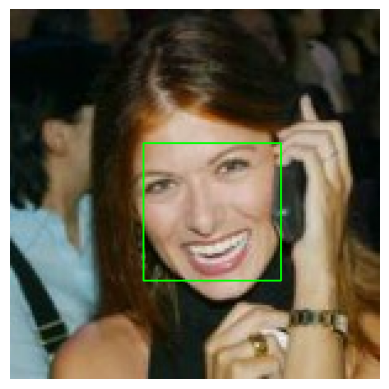

Processing: Assignment5_Files\faces\Debra_Messing_0002.jpg


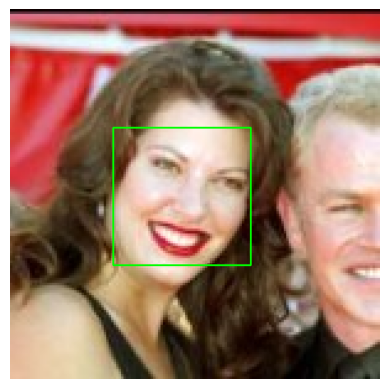

Processing: Assignment5_Files\faces\Elisabeth_Schumacher_0001.jpg
No Face Detected in Assignment5_Files\faces\Elisabeth_Schumacher_0001.jpg
Processing: Assignment5_Files\faces\Janica_Kostelic_0001.jpg


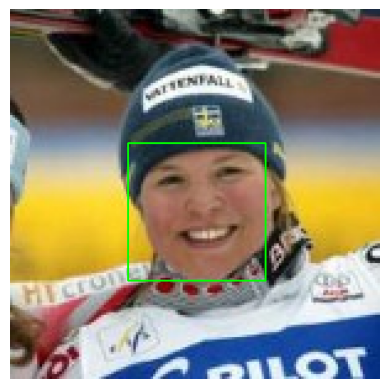

Processing: Assignment5_Files\faces\Jim_OBrien_0001.jpg


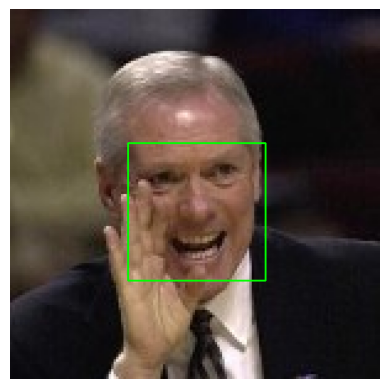

Processing: Assignment5_Files\faces\Jim_OBrien_0002.jpg


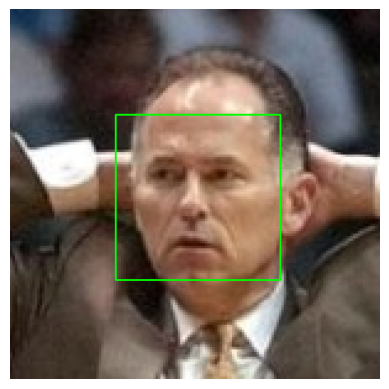

Processing: Assignment5_Files\faces\Martha_Bowen_0002.jpg


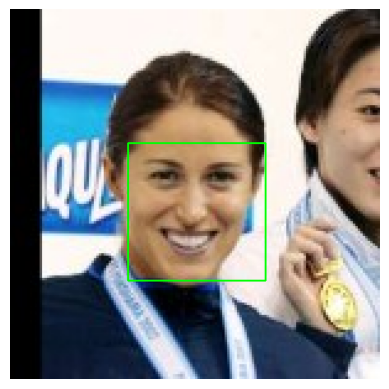

Processing: Assignment5_Files\faces\Nora_Bendijo_0002.jpg


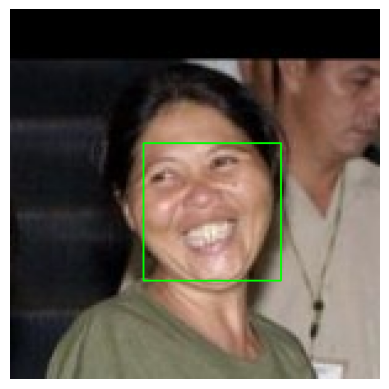

Debra_Messing_0001.jpg | GT: (190, 178, 253, 300) | Pred: (216, 217, 223, 223) | IoU: 0.6552
Debra_Messing_0002.jpg | GT: (134, 145, 279, 313) | Pred: (167, 192, 223, 223) | IoU: 0.5695
Elisabeth_Schumacher_0001.jpg | No detection | IoU: 0.0
Janica_Kostelic_0001.jpg | GT: (201, 240, 229, 210) | Pred: (191, 217, 223, 223) | IoU: 0.7715
Jim_OBrien_0001.jpg | GT: (148, 140, 246, 330) | Pred: (191, 217, 223, 223) | IoU: 0.5286
Jim_OBrien_0002.jpg | GT: (195, 117, 256, 358) | Pred: (171, 171, 267, 268) | IoU: 0.6640
Martha_Bowen_0002.jpg | GT: (166, 154, 230, 302) | Pred: (191, 217, 223, 223) | IoU: 0.6222
Nora_Bendijo_0002.jpg | GT: (193, 156, 239, 300) | Pred: (216, 217, 223, 223) | IoU: 0.6575


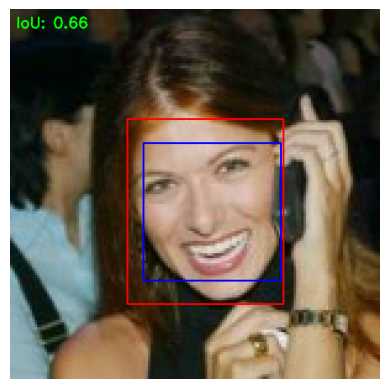

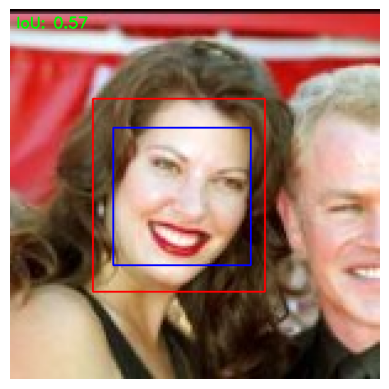

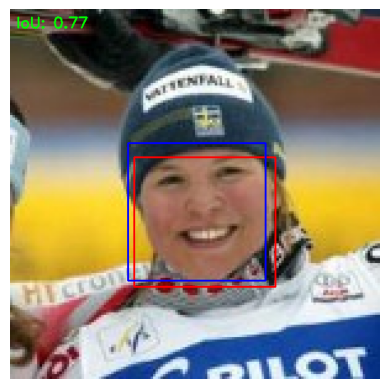

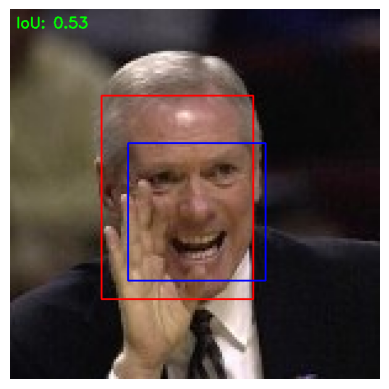

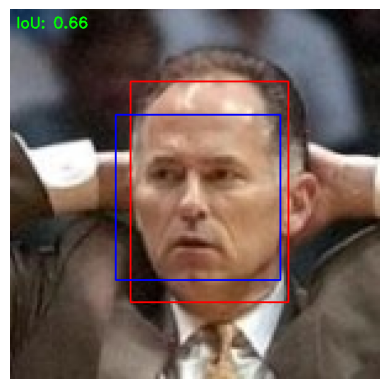

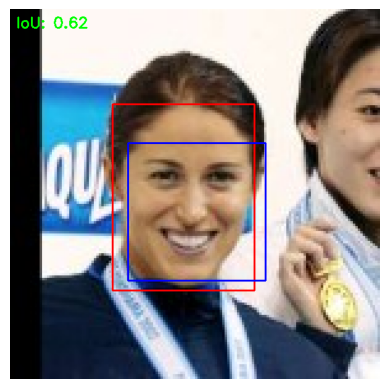

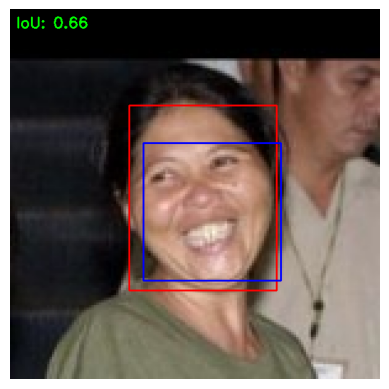

Average IoU: 0.5585
Threshold: 0.0 | Precision: 1.00 | Recall: 1.00 | F1: 1.00
Threshold: 0.1 | Precision: 0.88 | Recall: 0.88 | F1: 0.88
Threshold: 0.2 | Precision: 0.88 | Recall: 0.88 | F1: 0.88
Threshold: 0.3 | Precision: 0.88 | Recall: 0.88 | F1: 0.88
Threshold: 0.4 | Precision: 0.88 | Recall: 0.88 | F1: 0.88
Threshold: 0.5 | Precision: 0.88 | Recall: 0.88 | F1: 0.88
Threshold: 0.6 | Precision: 0.62 | Recall: 0.62 | F1: 0.62
Threshold: 0.7 | Precision: 0.12 | Recall: 0.12 | F1: 0.12
Threshold: 0.8 | Precision: 0.00 | Recall: 0.00 | F1: 0.00
Threshold: 0.9 | Precision: 0.00 | Recall: 0.00 | F1: 0.00


In [25]:
import dlib
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import imutils
import csv
import os

# Paths
base_path = 'Assignment5_Files'
faces_path = os.path.join(base_path, 'faces')
list_file = os.path.join(base_path, 'list.csv')
gt_file = os.path.join(base_path, 'gt.csv')
alg_file = os.path.join(base_path, 'detections.csv')

# Initialize dlib face detector
frontalface_detector = dlib.get_frontal_face_detector()

# Convert dlib rectangle to (x, y, w, h)
def rect_to_bb(rect):
    x = rect.left()
    y = rect.top()
    w = rect.right() - x
    h = rect.bottom() - y
    return (x, y, w, h)

# IoU function
def intersection_over_union(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[0] + boxA[2], boxB[0] + boxB[2])
    yB = min(boxA[1] + boxA[3], boxB[1] + boxB[3])
    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = boxA[2] * boxA[3]
    boxBArea = boxB[2] * boxB[3]
    return interArea / float(boxAArea + boxBArea - interArea)

# Detect faces and save results
def detect_face(image_path):
    try:
        image = cv.imread(image_path)
        if image is None:
            print(f"Error loading image: {image_path}")
            return None

        image = imutils.resize(image, width=600)
        rgb = cv.cvtColor(image, cv.COLOR_BGR2RGB)

        rects = frontalface_detector(rgb, 1)

        if len(rects) < 1:
            print(f"No Face Detected in {image_path}")
            return None

        detections = []
        with open(alg_file, 'a', newline='') as file:
            writer = csv.writer(file)
            for (i, rect) in enumerate(rects):
                (x, y, w, h) = rect_to_bb(rect)
                detections.append((x, y, w, h))
                cv.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)
                writer.writerow([os.path.basename(image_path), x, y, w, h])

        # Display image with bounding boxes
        plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()

        return detections
    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return None

# Step 1: Run detection on all images
with open(list_file, 'r') as file:
    reader = csv.reader(file)
    for row in reader:
        img_path = os.path.join(faces_path, row[0])
        print(f"Processing: {img_path}")
        detect_face(img_path)

# Step 2: Load ground truth and predictions
gt_dict = {}
with open(gt_file, 'r') as file:
    reader = csv.reader(file)
    for row in reader:
        gt_dict[os.path.basename(row[0])] = (int(row[1]), int(row[2]), int(row[3]), int(row[4]))

pred_dict = {}
if os.path.exists(alg_file):
    with open(alg_file, 'r') as file:
        reader = csv.reader(file)
        for row in reader:
            pred_dict[os.path.basename(row[0])] = (int(row[1]), int(row[2]), int(row[3]), int(row[4]))


# Step 3: Compute IoU for each file
iou_list = []
for fname in gt_dict.keys():
    if fname in pred_dict:
        iou = intersection_over_union(gt_dict[fname], pred_dict[fname])
        iou_list.append(iou)
        print(f"{fname} | GT: {gt_dict[fname]} | Pred: {pred_dict[fname]} | IoU: {iou:.4f}")
    else:
        iou_list.append(0.0)
        print(f"{fname} | No detection | IoU: 0.0")

# Step 4: Draw bounding boxes and IoU on image
def draw_boxes(image_path, gt_box, pred_box, iou):
    image = cv.imread(image_path)
    image = imutils.resize(image, width=600)
    cv.rectangle(image, (gt_box[0], gt_box[1]), (gt_box[0]+gt_box[2], gt_box[1]+gt_box[3]), (0, 0, 255), 2)  # Blue GT
    cv.rectangle(image, (pred_box[0], pred_box[1]), (pred_box[0]+pred_box[2], pred_box[1]+pred_box[3]), (255, 0, 0), 2)  # Red Pred
    cv.putText(image, f"IoU: {iou:.2f}", (10, 30), cv.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
    plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

# Show samples
samples = list(gt_dict.keys())[:8]
for fname in samples:
    if fname in pred_dict:
        draw_boxes(os.path.join(faces_path, fname), gt_dict[fname], pred_dict[fname], intersection_over_union(gt_dict[fname], pred_dict[fname]))

# Step 5: Average IoU
avg_iou = np.mean(iou_list)
print(f"Average IoU: {avg_iou:.4f}")

# Step 6: Precision, Recall, F1
def compute_metrics(iou_list, num_files, threshold):
    tp = sum(1 for iou in iou_list if iou >= threshold)
    fp = sum(1 for iou in iou_list if iou < threshold)
    fn = num_files - tp
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return precision, recall, f1

num_files = len(gt_dict)
for threshold in np.arange(0, 1.0, 0.1):
    precision, recall, f1 = compute_metrics(iou_list, num_files, threshold)
    print(f"Threshold: {threshold:.1f} | Precision: {precision:.2f} | Recall: {recall:.2f} | F1: {f1:.2f}")